# Основная часть

## Загрузка данных и первичный анализ 

### Импорт библиотек и загрузка данных из датасета 

In [86]:
# Базовые библиотеки
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt

# Разделение данных и CV
from sklearn.model_selection import train_test_split, GridSearchCV

# Baseline-модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Pipeline и масштабирование
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Деревья решений и ансамбли деревьев
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Метрики
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Интерпретация
from sklearn.inspection import permutation_importance

# Сохранение артефактов
import json
import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Загрузка данных из датасета
df = pd.read_csv("S06-hw-dataset-02.csv")

### Первиный просмотр данных 

In [87]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


### Служебная информация о данных

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

### Базовые статистики

In [89]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,...,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,...,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,...,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,...,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,...,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,...,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,...,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


### Распределение таргета

In [90]:
# Колличество
df["target"].value_counts()

target
0    13273
1     4727
Name: count, dtype: int64

In [91]:
# Доли
df["target"].value_counts(normalize=True)

target
0    0.737389
1    0.262611
Name: proportion, dtype: float64

### Cколько объектов каждого класса

In [92]:
df["target"].value_counts()

target
0    13273
1     4727
Name: count, dtype: int64

Датасет бинарный, классы умеренно несбалансированы: класс 0 встречается чаще, чем класс 1, но перекос не экстремальный.

### Доли классов

In [93]:
df["target"].value_counts(normalize=True)

target
0    0.737389
1    0.262611
Name: proportion, dtype: float64

### Проверка пропусков

In [94]:
df.isna().sum()

id         0
f01        0
f02        0
f03        0
f04        0
f05        0
f06        0
f07        0
f08        0
f09        0
f10        0
f11        0
f12        0
f13        0
f14        0
f15        0
f16        0
f17        0
f18        0
f19        0
f20        0
f21        0
f22        0
f23        0
f24        0
f25        0
f26        0
f27        0
f28        0
f29        0
f30        0
f31        0
f32        0
f33        0
f34        0
f35        0
x_int_1    0
x_int_2    0
target     0
dtype: int64

### Определяем X и Y

In [95]:
X = df.drop(columns=["target"])
y = df["target"]

## Train/Test-сплит и воспроизводимость

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

Для воспроизводимости результатов зафиксирован random_state.
Параметр stratify=y используется для сохранения долей классов в train и test, что особенно важно при умеренном дисбалансе.

## Baseline’ы

### Создаем Pipeline

In [97]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

### Обучаем модель на train

In [98]:
logreg_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

### Предсказания на test

In [99]:
y_pred_logreg = logreg_pipe.predict(X_test)

### Считаем метрики

In [100]:
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg)

In [101]:
y_proba_logreg = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_roc_auc = roc_auc_score(y_test, y_proba_logreg)


LogisticRegression используется как сильный baseline.
Масштабирование признаков выполнено с помощью StandardScaler внутри Pipeline, чтобы избежать утечки информации и обеспечить корректное обучение модели.

## Модели недели 6


### Задаем модель

In [102]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

### Сетка гиперпараметров

In [103]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10]
}

### GridSearchCV

In [104]:
dt_grid = GridSearchCV(
    dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

Для DecisionTreeClassifier выполнен подбор гиперпараметров max_depth и
min_samples_leaf с помощью GridSearchCV на обучающей выборке.
Контроль сложности позволяет снизить риск переобучения.

### RandomForestClassifier

In [112]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_


### GradientBoostingClassifier

In [119]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    gb,
    param_grid=gb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

### Лучшая модель и оценка на test

In [117]:
best_dt = dt_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

## Метрики кечества 

### Используем уже обученные модели

### Явное создание DummyClassifier (baseline)

In [120]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [121]:
models = {
    "DummyClassifier": dummy_clf,
    "LogisticRegression": logreg_pipe,
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "GradientBoosting": best_gb
}

### Предсказания и вероятности

In [122]:
y_preds = {}
y_probas = {}

for name, model in models.items():
    y_preds[name] = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_probas[name] = model.predict_proba(X_test)[:, 1]

### Расчёт метрик

In [123]:
metrics_test = {}

for name in y_preds:
    metrics_test[name] = {
        "accuracy": accuracy_score(y_test, y_preds[name]),
        "f1": f1_score(y_test, y_preds[name])
    }
    
    if name in y_probas:
        metrics_test[name]["roc_auc"] = roc_auc_score(y_test, y_probas[name])

metrics_test

{'DummyClassifier': {'accuracy': 0.7373333333333333,
  'f1': 0.0,
  'roc_auc': 0.5},
 'LogisticRegression': {'accuracy': 0.816,
  'f1': 0.5714285714285714,
  'roc_auc': 0.8008835567468222},
 'DecisionTree': {'accuracy': 0.8366666666666667,
  'f1': 0.6660608814175375,
  'roc_auc': 0.8229134475439815},
 'RandomForest': {'accuracy': 0.8902222222222222,
  'f1': 0.7542288557213931,
  'roc_auc': 0.9263352538428039},
 'GradientBoosting': {'accuracy': 0.9033333333333333,
  'f1': 0.7987043035631652,
  'roc_auc': 0.9264201621876877}}

### ROC-кривые

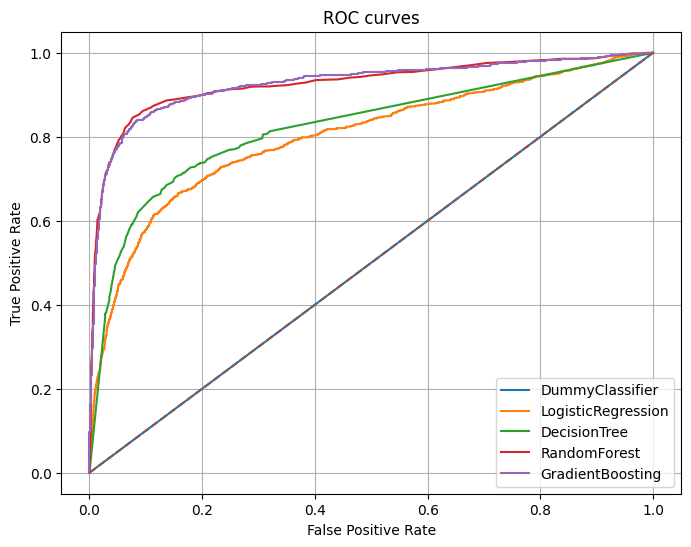

'artifacts\\figures\\roc_curves.png'

In [141]:
plt.figure(figsize=(8, 6))

for name, y_proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.grid(True)

roc_path = os.path.join(FIGURES_DIR, "roc_curves.png")
plt.savefig(roc_path, bbox_inches="tight")
plt.show()

roc_path

### Confusion Matrix лучшей модели

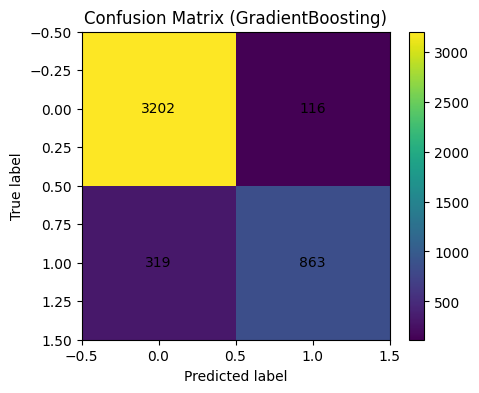

'artifacts\\figures\\confusion_matrix.png'

In [142]:
best_model_name = max(
    (name for name in metrics_test if "roc_auc" in metrics_test[name]),
    key=lambda name: metrics_test[name]["roc_auc"]
)

cm = confusion_matrix(y_test, y_preds[best_model_name])

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix ({best_model_name})")
plt.colorbar()

plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

cm_path = os.path.join(FIGURES_DIR, "confusion_matrix.png")
plt.savefig(cm_path, bbox_inches="tight")
plt.show()

cm_path

Ансамблевые модели демонстрируют более высокие значения F1 и ROC-AUC
по сравнению с baseline-моделями, что подтверждает их преимущество
на более сложных и шумных данных.

## Интерпретация модели

### Выбор лучшей модели по ROC-AUC


In [126]:
best_model_name = max(
    (name for name in metrics_test if "roc_auc" in metrics_test[name]),
    key=lambda name: metrics_test[name]["roc_auc"]
)

best_model = models[best_model_name]

best_model_name

'GradientBoosting'

### Permutation importance для лучшей модели

In [127]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

### Таблица важностей признаков


In [128]:
importances_df = (
    pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

importances_df.head(10)

,feature,importance_mean,importance_std
16,f16,0.093333,0.004015
1,f01,0.040311,0.003392
8,f08,0.017489,0.001988
23,f23,0.016022,0.002057
7,f07,0.015222,0.001784
30,f30,0.015111,0.001587
13,f13,0.014156,0.002145
18,f18,0.013911,0.002388
29,f29,0.012911,0.002055
15,f15,0.012822,0.001581


### График permutation importance

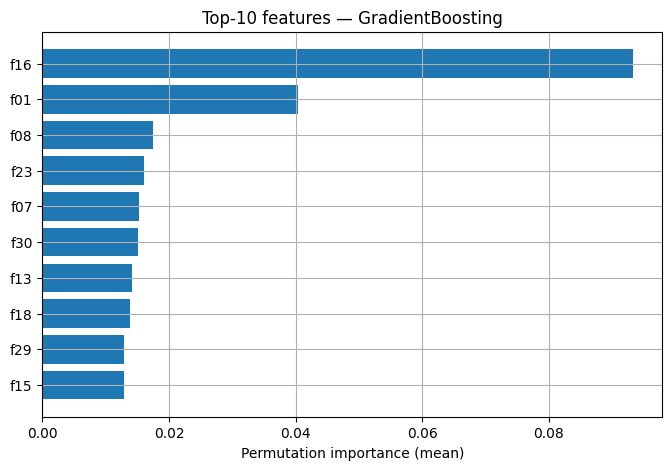

In [129]:
top_k = 10
top_features = importances_df.head(top_k)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance_mean"][::-1]
)
plt.xlabel("Permutation importance (mean)")
plt.title(f"Top-{top_k} features — {best_model_name}")
plt.grid(True)
plt.show()

Permutation importance показывает, какие признаки оказывают наибольшее влияние
на качество предсказаний лучшей модели. Наиболее важные признаки соответствуют
ожиданиям для синтетического датасета и отражают наличие нелинейных взаимодействий.
Менее значимые признаки вносят ограниченный вклад в итоговое качество модели.

# Артефакты эксперимента

## Создание структуры папок для артефактов

In [131]:
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

ARTIFACTS_DIR, FIGURES_DIR

('artifacts', 'artifacts\\figures')

### Сохранение финальных метрик на test

In [132]:
metrics_path = os.path.join(ARTIFACTS_DIR, "metrics_test.json")

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_test, f, indent=4)

metrics_path


'artifacts\\metrics_test.json'

### Сохранение результатов подбора гиперпараметров

In [133]:
search_summaries = {}

# DecisionTree
search_summaries["DecisionTree"] = {
    "best_params": dt_grid.best_params_,
    "best_cv_score": dt_grid.best_score_
}

# RandomForest
search_summaries["RandomForest"] = {
    "best_params": rf_grid.best_params_,
    "best_cv_score": rf_grid.best_score_
}

# GradientBoosting
search_summaries["GradientBoosting"] = {
    "best_params": gb_grid.best_params_,
    "best_cv_score": gb_grid.best_score_
}

search_path = os.path.join(ARTIFACTS_DIR, "search_summaries.json")

with open(search_path, "w", encoding="utf-8") as f:
    json.dump(search_summaries, f, indent=4)

search_path

'artifacts\\search_summaries.json'

### Сохранение лучшей модели

In [134]:
best_model_path = os.path.join(ARTIFACTS_DIR, "best_model.joblib")

joblib.dump(best_model, best_model_path)

best_model_path


'artifacts\\best_model.joblib'

### Метаданные лучшей модели

In [135]:
best_model_meta = {
    "model_name": best_model_name,
    "test_metrics": metrics_test[best_model_name]
}

best_model_meta_path = os.path.join(ARTIFACTS_DIR, "best_model_meta.json")

with open(best_model_meta_path, "w", encoding="utf-8") as f:
    json.dump(best_model_meta, f, indent=4)

best_model_meta_path


'artifacts\\best_model_meta.json'